In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("matches.csv")
print(df)

           id   season        city        date   match_type  player_of_match  \
0      335982  2007/08   Bangalore  18-04-2008       League      BB McCullum   
1      335983  2007/08  Chandigarh  19-04-2008       League       MEK Hussey   
2      335984  2007/08       Delhi  19-04-2008       League      MF Maharoof   
3      335985  2007/08      Mumbai  20-04-2008       League       MV Boucher   
4      335986  2007/08     Kolkata  20-04-2008       League        DJ Hussey   
...       ...      ...         ...         ...          ...              ...   
1090  1426307     2024   Hyderabad  19-05-2024       League  Abhishek Sharma   
1091  1426309     2024   Ahmedabad  21-05-2024  Qualifier 1         MA Starc   
1092  1426310     2024   Ahmedabad  22-05-2024   Eliminator         R Ashwin   
1093  1426311     2024     Chennai  24-05-2024  Qualifier 2    Shahbaz Ahmed   
1094  1426312     2024     Chennai  26-05-2024        Final         MA Starc   

                                       

In [5]:
print(df.columns)

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')


In [6]:
print(df.dtypes)

id                   int64
season              object
city                object
date                object
match_type          object
player_of_match     object
venue               object
team1               object
team2               object
toss_winner         object
toss_decision       object
winner              object
result              object
result_margin      float64
target_runs        float64
target_overs       float64
super_over          object
method              object
umpire1             object
umpire2             object
dtype: object


In [7]:
df["date"] = pd.to_datetime(df["date"], format="%d-%m-%Y")

In [8]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

In [10]:
print(df.groupby("toss_winner")["winner"].count())

toss_winner
CDelhi     50
CSK       121
DC         43
Delhi      79
GT         41
Gujrat     15
KKR       122
Kerala      8
MI        143
Pune       20
Punjab    109
RCB       120
RPune      13
RR        118
SRH        88
Name: winner, dtype: int64


In [9]:
print(df.columns)


Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2', 'year', 'month', 'day'],
      dtype='object')


In [57]:
print(len(df))

1095


In [45]:
print(df.groupby("winner")["result"].count())

winner
CDelhi     48
CSK       138
DC         29
Delhi      67
GT         52
Gujrat     13
KKR       131
Kerala      6
MI        144
Pune       12
Punjab    112
RCB       123
RPune      15
RR        112
SRH        88
Name: result, dtype: int64


In [58]:
print(df["season"].nunique())

17


In [66]:
print(df["winner"].value_counts().max())
print(df["winner"].value_counts().idxmax())

144
MI


In [65]:
print(df["toss_winner"].value_counts().idxmax())
print(df["toss_winner"].value_counts().max())

MI
143


In [61]:
print((df["toss_winner"] == df["winner"]).sum())

555


In [64]:
print(df["toss_decision"].value_counts().idxmax())
print(df["toss_decision"].value_counts())

field
toss_decision
field    704
bat      391
Name: count, dtype: int64


In [67]:
print(df["season"].value_counts().idxmax())
print(df["season"].value_counts().max())

2013
76


In [68]:
print((df["result"] == "runs").sum())
print((df["result"] == "wickets").sum())

498
578


In [69]:
print(df.loc[df["result_margin"].idxmax(), ["winner", "result", "result_margin"]])

winner              MI
result            runs
result_margin    146.0
Name: 620, dtype: object


In [70]:
print(df["player_of_match"].value_counts().idxmax())
print(df["player_of_match"].value_counts().max())

AB de Villiers
25


In [71]:
print((df["super_over"] == "Y").sum())

14


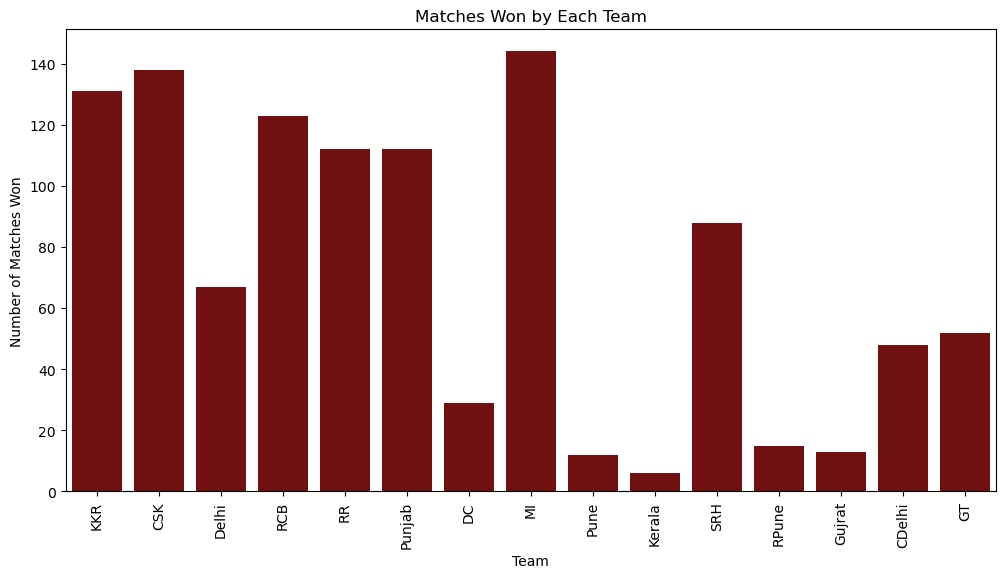

In [49]:
# Matches Won By Each Team
plt.figure(figsize=(12, 6))

sns.countplot(data=df, x="winner", color="maroon")

plt.xlabel("Team")
plt.ylabel("Number of Matches Won")
plt.title("Matches Won by Each Team")

plt.xticks(rotation=90)

plt.show()

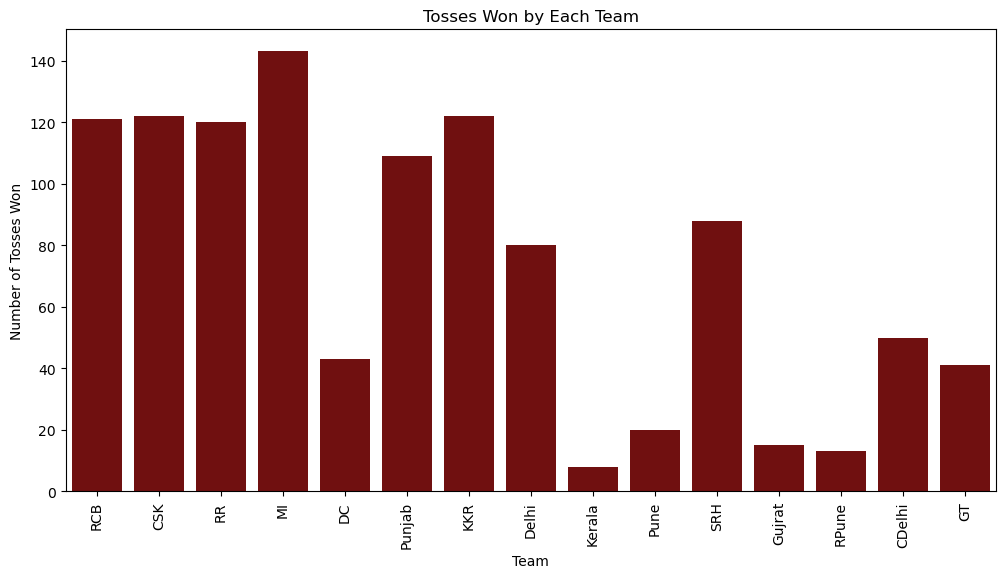

In [48]:
# Tosses Won By Each Team
plt.figure(figsize=(12, 6))

sns.countplot(data=df, x="toss_winner", color="maroon")

plt.xlabel("Team")
plt.ylabel("Number of Tosses Won")
plt.title("Tosses Won by Each Team")

plt.xticks(rotation=90)
plt.show()

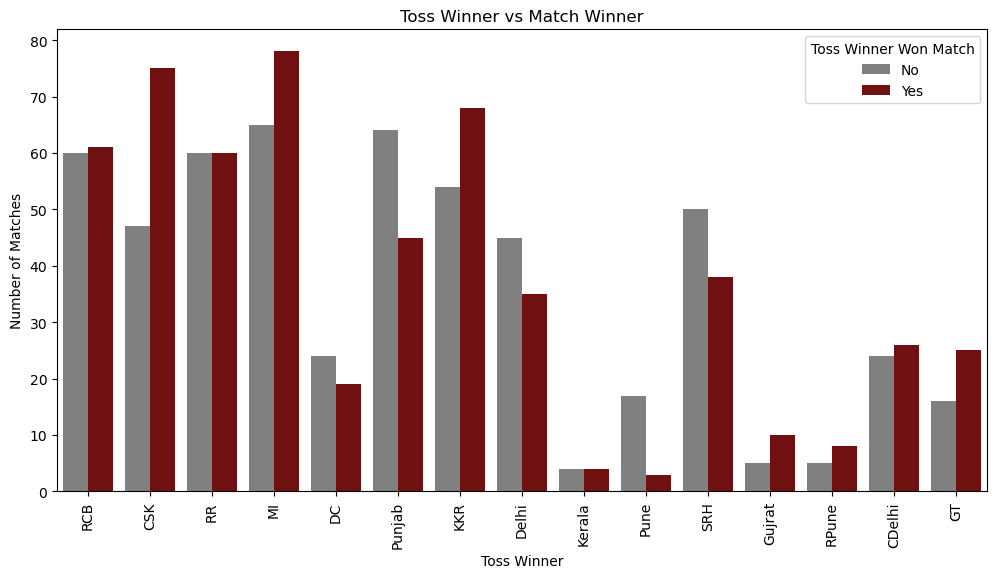

In [50]:
# Toss Winner vs Match Winner
plt.figure(figsize=(12, 6))

sns.countplot( data=df, x="toss_winner", hue=df["toss_winner"] == df["winner"], palette=["grey", "maroon"])

plt.xlabel("Toss Winner")
plt.ylabel("Number of Matches")
plt.title("Toss Winner vs Match Winner")

plt.xticks(rotation=90)
plt.legend(title="Toss Winner Won Match", labels=["No", "Yes"])

plt.show()

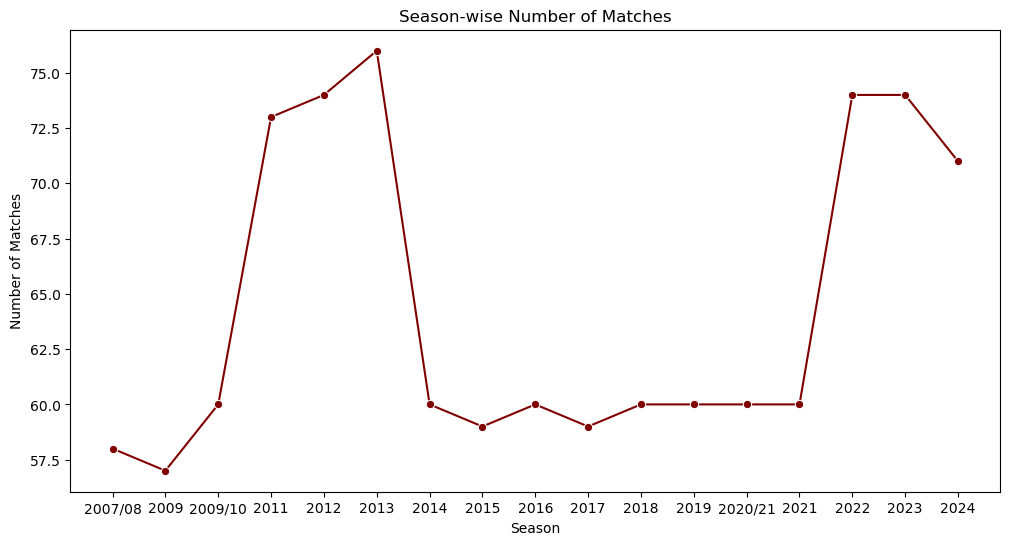

In [51]:
# Season-wise Number of Matches
plt.figure(figsize=(12, 6))

sns.lineplot(data=df.groupby("season").size(),marker="o", color="maroon")

plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.title("Season-wise Number of Matches")

plt.show()

C:\Users\Tanveer\AppData\Local\Temp\ipykernel_4220\1829435632.py:3: UserWarning: 
The palette list has fewer values (5) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=df, x="season",hue="winner",palette=["maroon", "grey", "rosybrown", "lightcoral", "brown"])


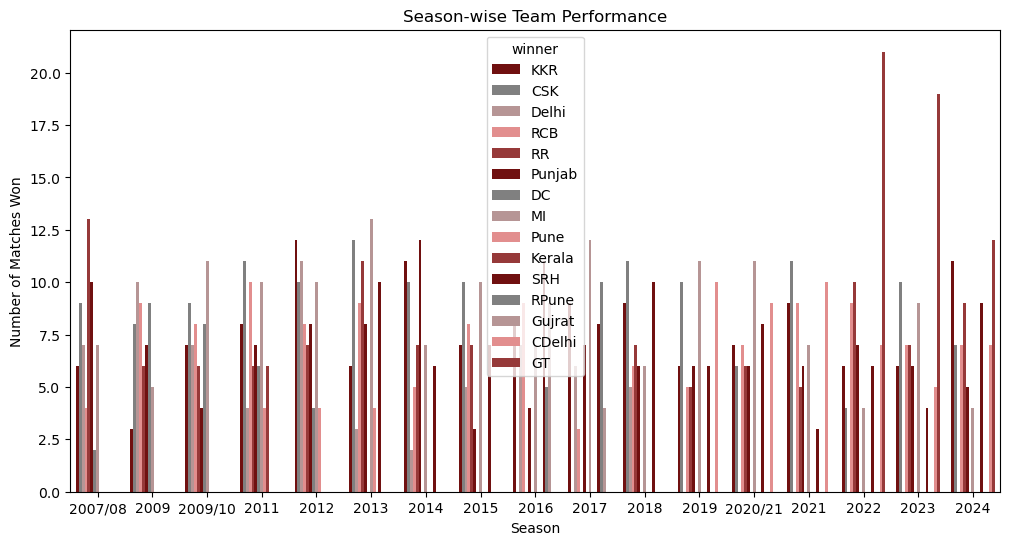

In [52]:
# Season-wise Team Performance
plt.figure(figsize=(12, 6))

sns.countplot(data=df, x="season",hue="winner",palette=["maroon", "grey", "rosybrown", "lightcoral", "brown"])

plt.xlabel("Season")
plt.ylabel("Number of Matches Won")
plt.title("Season-wise Team Performance")

plt.show()

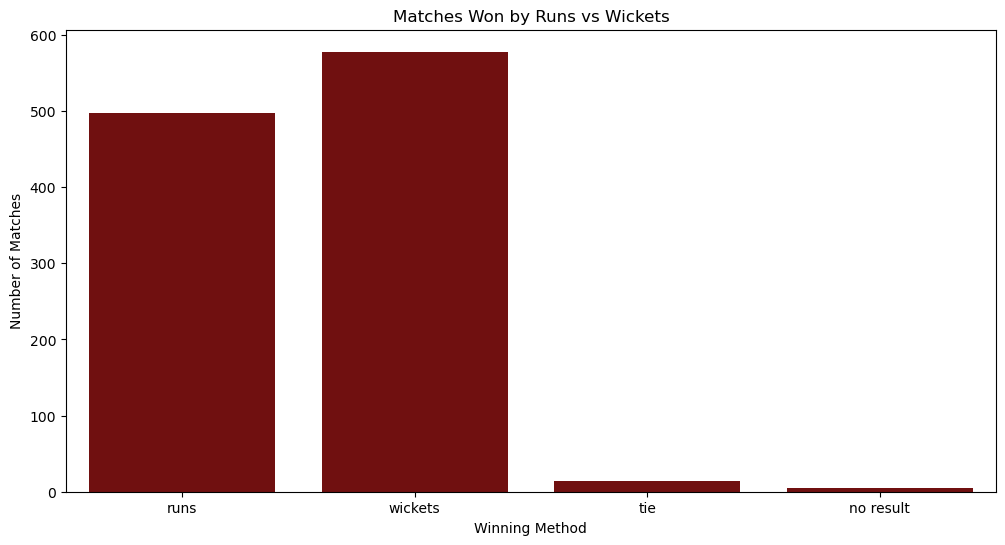

In [54]:
# Matches Won by Runs vs Wickets
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="result",
    color="maroon"
)

plt.xlabel("Winning Method")
plt.ylabel("Number of Matches")
plt.title("Matches Won by Runs vs Wickets")

plt.show()

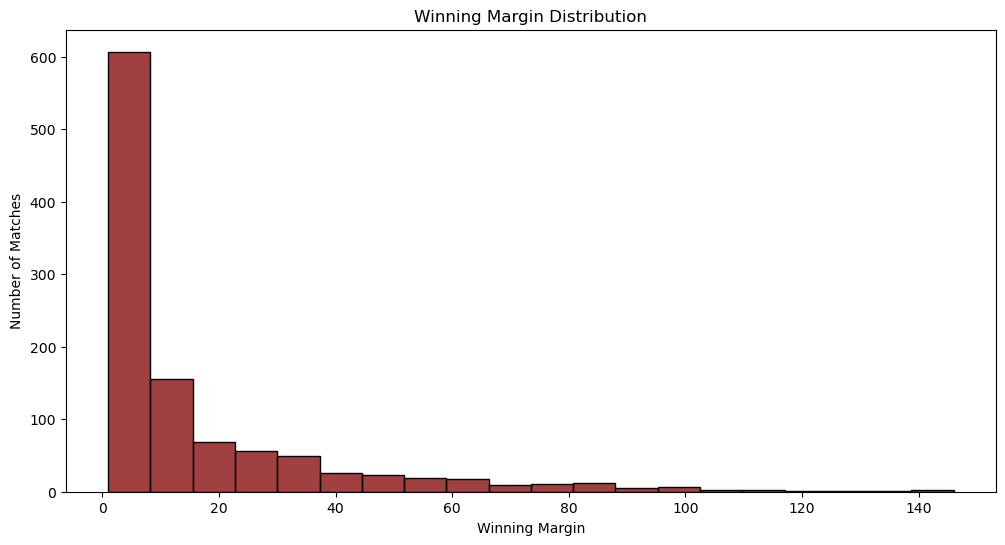

In [55]:
# Winning Margin Distribution
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="result_margin",
    color="maroon",
    bins=20
)

plt.xlabel("Winning Margin")
plt.ylabel("Number of Matches")
plt.title("Winning Margin Distribution")

plt.show()

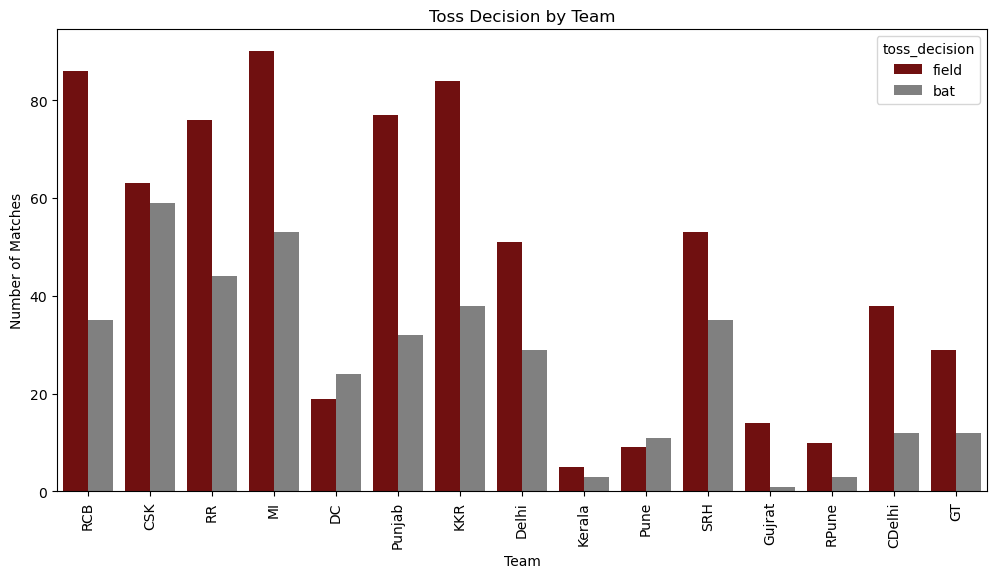

In [56]:
# Toss Decision by Team
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df,
    x="toss_winner",
    hue="toss_decision",
    palette=["maroon", "grey"]
)
plt.xlabel("Team")
plt.ylabel("Number of Matches")
plt.title("Toss Decision by Team")

plt.xticks(rotation=90)

plt.show()